** Berlin Public Funding Priorities Analysis (2020–2024)**
Objective:
Understand how public funding priorities evolved across policy areas in Berlin between 2020 and 2024:.

Research Questions:
- Which policy areas received the most funding?
- How did funding priorities change over time?
- What is the balance between project funding and institutional funding?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files

uploaded = files.upload()

Saving database_berlin_grants.xlsx to database_berlin_grants.xlsx


In [6]:
df = pd.read_excel("database_berlin_grants.xlsx")
df.head()


,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
0,60658,Forschungsverbund Berlin e. V. \n(FVB),Senatskanzlei - Forschung -,institutionelle Förderung,2020,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,114826400,vr_012174
1,60679,Forschungsverbund Berlin e. V. \n(FVB),"Senatsverwaltung für Wissenschaft, Gesundheit ...",institutionelle Förderung,2024,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,104679900,vr_012174
2,60691,Forschungsverbund Berlin e. V. \n(FVB),"Senatsverwaltung für Wissenschaft, Gesundheit,...",institutionelle Förderung,2023,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,101979700,vr_012174
3,60685,Forschungsverbund Berlin e. V. \n(FVB),"Senatsverwaltung für Wissenschaft, Gesundheit,...",institutionelle Förderung,2022,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,94852300,vr_012174
4,60667,Forschungsverbund Berlin e. V. \n(FVB),Senatskanzlei - Forschung -,institutionelle Förderung,2021,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,91793100,vr_012174


In [7]:
df.shape

(57469, 10)

In [8]:
df.columns

Index(['id', 'name', 'geber', 'art', 'jahr', 'anschrift', 'politikbereich',
       'zweck', 'betrag', 'empfaengerid'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57469 entries, 0 to 57468
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57469 non-null  int64 
 1   name            57469 non-null  object
 2   geber           57469 non-null  object
 3   art             57469 non-null  object
 4   jahr            57469 non-null  int64 
 5   anschrift       57469 non-null  object
 6   politikbereich  57469 non-null  object
 7   zweck           57468 non-null  object
 8   betrag          57469 non-null  int64 
 9   empfaengerid    55987 non-null  object
dtypes: int64(3), object(7)
memory usage: 4.4+ MB


- How many registers are per year?

In [10]:
df['jahr'].value_counts().sort_index()

,count
jahr,
2020,11281
2021,14011
2022,10615
2023,11753
2024,9809


- How did total public funding envolve between 2020 and 2024?

In [12]:
df.groupby('jahr')['betrag'].sum().sort_index()

,betrag
jahr,
2020,2870514492
2021,2703000698
2022,2259910184
2023,3123201707
2024,2644024962


- Which policy areas received the highest levels of funding?

In [16]:
funding_by_policy = (
    df.groupby('politikbereich')['betrag']
    .sum()
    .sort_values(ascending=False)
)
funding_by_policy.head(10)

,betrag
politikbereich,
Wirtschaft,2267632043
Arbeit,1959637273
Forschung,1742715162
Kultur,1107110050
Verkehr,1106371848
Stadtentwicklung,794201351
Jugend,724363859
Wissenschaft,568006796
Gesundheit,537151489


- Funding by policy area and year

In [18]:
policy_year = (
    df.groupby(['jahr', 'politikbereich'])['betrag']
    .sum()
    .reset_index()
)
policy_year

,jahr,politikbereich,betrag
0,2020,Antidiskriminierung,13642184
1,2020,Arbeit,452273412
2,2020,"Bauen, Wohnen",1268261
3,2020,Berlin-Image,243000
4,2020,Bildung,88646992
...,...,...,...
154,2024,Umwelt,139760333
155,2024,Verbraucherschutz,5465830
156,2024,Verkehr,169696646
157,2024,Wirtschaft,583655906


- Building a pivot table

In [19]:
policy_pivot = (
    df.pivot_table(
        values = 'betrag',
        index = 'jahr',
        columns = 'politikbereich',
        aggfunc = 'sum'
    )
)
policy_pivot

politikbereich,Antidiskriminierung,Arbeit,"Bauen, Wohnen",Berlin-Image,Bildung,Bürgerschaftliches Engagement,"Bürgerschaftliches Engagement, Bürgerbeteiligung",Denkmalschutz,Europa,Familie,...,Soziales,Sport,Stadtentwicklung,Tierschutz,Umwelt,Verbraucherschutz,Verkehr,Wirtschaft,Wissenschaft,kultur
jahr,,,,,,,,,,,,,,,,,,,,,
2020,13642184.0,452273412.0,1268261.0,243000.0,88646992.0,NaN,4739472.0,2801739.0,615435.0,56414482.0,...,85236014.0,35171107.0,440716084.0,252525.0,70013509.0,5074420.0,311388790.0,315252377.0,125459064.0,NaN
2021,17806921.0,452193244.0,920261.0,858056.0,121972561.0,NaN,5820379.0,2762366.0,977069.0,56665366.0,...,94233709.0,42238519.0,127622318.0,NaN,97954780.0,5758320.0,200232505.0,444463850.0,99467199.0,188124.0
2022,17596288.0,345226411.0,1764762.0,NaN,94236232.0,NaN,6285424.0,3279643.0,1066462.0,65052255.0,...,85883338.0,44651499.0,44919504.0,NaN,100023700.0,5762773.0,210094387.0,262390190.0,94750789.0,27721.0
2023,21316332.0,430284679.0,1426300.0,NaN,119617254.0,103900.0,7587042.0,3389158.0,1660302.0,78050617.0,...,113504310.0,55129079.0,118493965.0,10000.0,102977909.0,6561221.0,214959520.0,661869720.0,125133960.0,108000.0
2024,26228941.0,279659527.0,1303984.0,1335091.0,55195714.0,NaN,12301542.0,10604031.0,1847687.0,51942461.0,...,101265652.0,44412269.0,62449480.0,4000.0,139760333.0,5465830.0,169696646.0,583655906.0,123195784.0,NaN


- Top 10 total funding

In [20]:
top10 = (
    df.groupby('politikbereich')['betrag']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top10

Index(['Wirtschaft', 'Arbeit', 'Forschung', 'Kultur', 'Verkehr',
       'Stadtentwicklung', 'Jugend', 'Wissenschaft', 'Gesundheit', 'Umwelt'],
      dtype='object', name='politikbereich')

In [21]:
policy_pivot_top10 = policy_pivot[top10]

policy_pivot_top10

politikbereich,Wirtschaft,Arbeit,Forschung,Kultur,Verkehr,Stadtentwicklung,Jugend,Wissenschaft,Gesundheit,Umwelt
jahr,,,,,,,,,,
2020,315252377.0,452273412.0,329423781.0,217514524.0,311388790.0,440716084.0,124707590.0,125459064.0,66312614.0,70013509.0
2021,444463850.0,452193244.0,333345619.0,221564807.0,200232505.0,127622318.0,125306388.0,99467199.0,123497977.0,97954780.0
2022,262390190.0,345226411.0,337565353.0,239835386.0,210094387.0,44919504.0,116932610.0,94750789.0,84652848.0,100023700.0
2023,661869720.0,430284679.0,340540756.0,272517065.0,214959520.0,118493965.0,176953685.0,125133960.0,129571351.0,102977909.0
2024,583655906.0,279659527.0,401839653.0,155678268.0,169696646.0,62449480.0,180463586.0,123195784.0,133116699.0,139760333.0


- Total per year policy

In [22]:
year_totals = policy_pivot.sum(axis=1)
year_totals

,0
jahr,
2020,2.870514e+09
2021,2.703001e+09
2022,2.259910e+09
2023,3.123202e+09
2024,2.644025e+09


- Percentage of total

In [23]:
policy_share = policy_pivot_top10.div(
   policy_pivot.sum(axis=1),
   axis=0
)*100

policy_share.round(2)

politikbereich,Wirtschaft,Arbeit,Forschung,Kultur,Verkehr,Stadtentwicklung,Jugend,Wissenschaft,Gesundheit,Umwelt
jahr,,,,,,,,,,
2020,10.98,15.76,11.48,7.58,10.85,15.35,4.34,4.37,2.31,2.44
2021,16.44,16.73,12.33,8.20,7.41,4.72,4.64,3.68,4.57,3.62
2022,11.61,15.28,14.94,10.61,9.30,1.99,5.17,4.19,3.75,4.43
2023,21.19,13.78,10.90,8.73,6.88,3.79,5.67,4.01,4.15,3.30
2024,22.07,10.58,15.20,5.89,6.42,2.36,6.83,4.66,5.03,5.29


- Graph policy share

<function matplotlib.pyplot.show(close=None, block=None)>

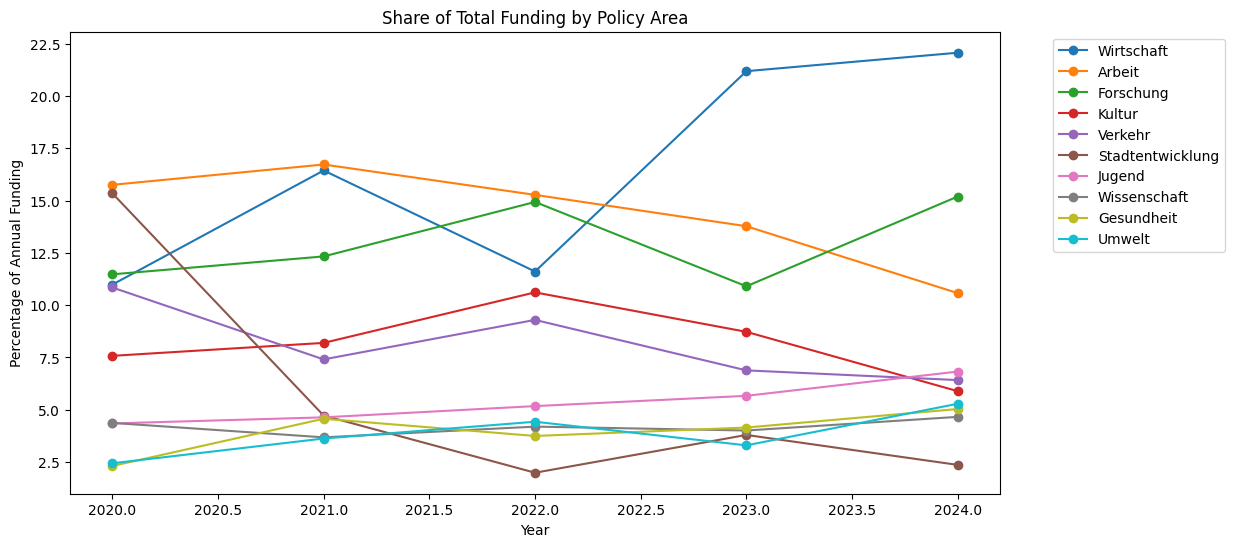

In [27]:
policy_share.plot(
    figsize=(12,6),
    marker='o'
)
plt.title('Share of Total Funding by Policy Area')
plt.ylabel('Percentage of Annual Funding')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show

In [28]:
policy_share.round(2)

politikbereich,Wirtschaft,Arbeit,Forschung,Kultur,Verkehr,Stadtentwicklung,Jugend,Wissenschaft,Gesundheit,Umwelt
jahr,,,,,,,,,,
2020,10.98,15.76,11.48,7.58,10.85,15.35,4.34,4.37,2.31,2.44
2021,16.44,16.73,12.33,8.20,7.41,4.72,4.64,3.68,4.57,3.62
2022,11.61,15.28,14.94,10.61,9.30,1.99,5.17,4.19,3.75,4.43
2023,21.19,13.78,10.90,8.73,6.88,3.79,5.67,4.01,4.15,3.30
2024,22.07,10.58,15.20,5.89,6.42,2.36,6.83,4.66,5.03,5.29


- Titulo que represente tabla comparativa de 2020 vs 2024

In [30]:
change = (
    policy_share.loc[2024] -
    policy_share.loc[2020]
)

change.round(2).sort_values(ascending=False)

,0
politikbereich,
Wirtschaft,11.09
Forschung,3.72
Umwelt,2.85
Gesundheit,2.72
Jugend,2.48
Wissenschaft,0.29
Kultur,-1.69
Verkehr,-4.43
Arbeit,-5.18


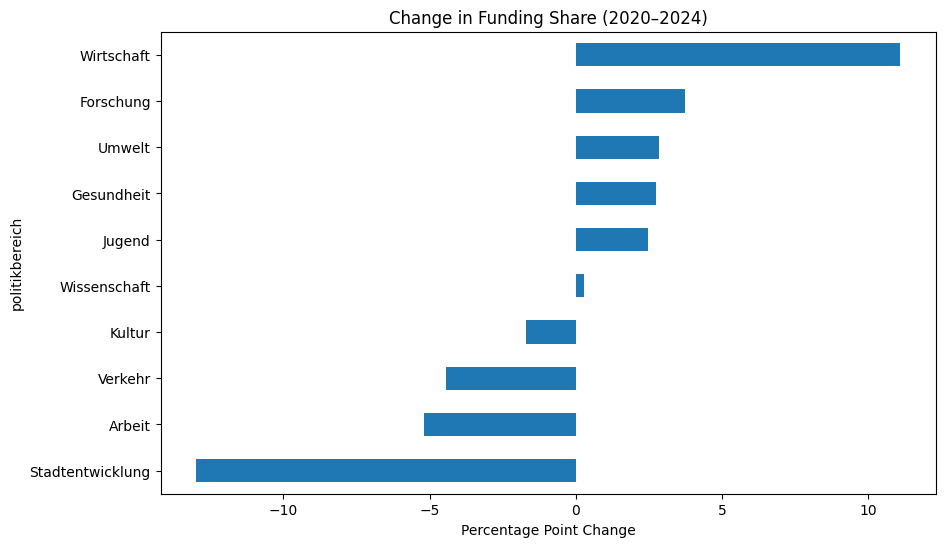

In [31]:
change.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Change in Funding Share (2020–2024)')
plt.xlabel('Percentage Point Change')
plt.show()